In [1]:
using JuMP, HiGHS, Gurobi, CPLEX, Random, PrettyTables, JSON, GeoJSON, CSV
using DataFrames
import Plots, Printf
import Distributions
import SparseArrays
using LinearAlgebra
using StatsPlots
using Distributions

In [2]:
input= CSV.read("Location.csv", DataFrame)
MRF_dx = input[1:7, 2]
S_dx = input[10:19, 2]
TS_dx = input[21:21, 2]
EM_dx = input[23:26,2]
MRF_dy = input[1:7, 3]
S_dy = input[10:19, 3]
TS_dy = input[21:21, 3]
EM_dy = input[23:26,3]
dS = [sqrt((S_dx[i] - S_dx[j])^2 + (S_dy[i] - S_dy[j])^2) for i in 1:length(S_dx), j in 1:length(S_dx)]
dS_TS = [sqrt((S_dx[i] - TS_dx[j])^2 + (S_dy[i] - TS_dy[j])^2) for i in 1:length(S_dx), j in 1:length(TS_dx)]
dS_MRF = [sqrt((S_dx[i] - MRF_dx[j])^2 + (S_dy[i] - MRF_dy[j])^2) for i in 1:length(S_dx), j in 1:length(MRF_dx)]
dTS_MRF = [sqrt((TS_dx[i] - MRF_dx[j])^2 + (TS_dy[i] - MRF_dy[j])^2) for i in 1:length(TS_dx), j in 1:length(MRF_dx)]
dMRF_EM = [sqrt((MRF_dx[i] - EM_dx[j])^2 + (MRF_dy[i] - EM_dy[j])^2) for i in 1:length(MRF_dx), j in 1:length(EM_dx)]
input_dataframe = (Spoke_lat = S_dx, Spoke_long = S_dy, TS_lat = TS_dx, TS_long = TS_dy, MRF_lat = MRF_dx, MRF_long = MRF_dy, EM_lat = EM_dx, EM_long = EM_dy)
pretty_table(input_dataframe, header = ["Spoke_lat", "Spoke_long", "TS_lat", "TS_long", "MRF_lat", "MRF_long", "EM_lat", "EM_long"])

┌───────────┬────────────┬────────┬──────────┬─────────┬──────────┬─────────┬──────────┐
│ Spoke_lat │ Spoke_long │ TS_lat │  TS_long │ MRF_lat │ MRF_long │  EM_lat │  EM_long │
├───────────┼────────────┼────────┼──────────┼─────────┼──────────┼─────────┼──────────┤
│   34.7003 │   -112.353 │ 34.579 │ -112.425 │ 33.7608 │ -112.116 │ 33.5999 │ -112.251 │
│    34.653 │   -112.345 │ #undef │   #undef │  33.417 │ -112.119 │ 33.4219 │ -112.092 │
│   34.6246 │   -112.322 │ #undef │   #undef │ 33.4432 │ -112.138 │ 33.4096 │ -111.869 │
│   34.5941 │   -112.299 │ #undef │   #undef │ 33.6812 │ -112.477 │ 33.4179 │ -112.004 │
│   34.5896 │   -112.435 │ #undef │   #undef │ 33.3813 │ -111.536 │  #undef │   #undef │
│   34.6671 │   -112.469 │ #undef │   #undef │ 32.2792 │ -111.005 │  #undef │   #undef │
│   34.5462 │   -112.484 │ #undef │   #undef │ 32.1751 │ -110.912 │  #undef │   #undef │
│   34.6197 │   -112.467 │ #undef │   #undef │  #undef │   #undef │  #undef │   #undef │
│   34.5982 │   -112.

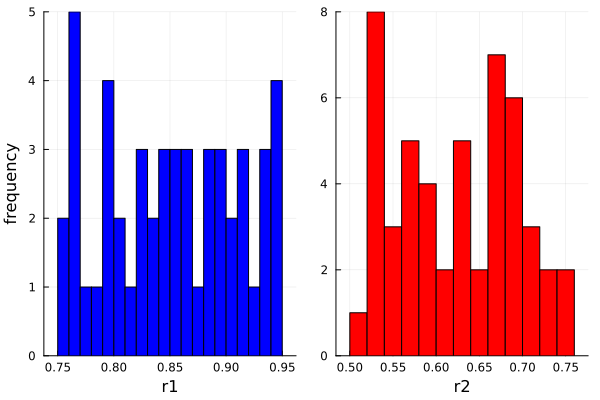

In [3]:
R1 = Distributions.Uniform(0.75, 0.95)
N = 50
Random.seed!(456)
r1 = sort!(rand(R1, N))

R2 = Distributions.Uniform(0.5, 0.75)
r2 = sort!(rand(R2, N))

# Create histograms
hist1 = histogram(r1, bins = 20, label = "", xlabel = "r1", ylabel = "frequency", color = :blue)
hist2 = histogram(r2, bins =20, label = "", xlabel = "r2", color = :red)

# Plot histograms side by side
plot(hist1, hist2; layout = @layout([a b]))

In [4]:
# Data
O = length(S_dx)
T = length(TS_dx)
M = length(MRF_dx)
E = length(EM_dx)
Ph = 8
Indicator = DataFrame(CSV.File("Indicator.csv"))
Comp = [0.33, 0.25, 0.1, 0.1, 0.05, 0.05, .02, 0.1] 
b= input[10:19, 7]
diagonal_values = ones(O) * 0
Rm = 200* rand(M, Ph)
# Generate random values for all elements
all_values = 20 * dS

# Create the final matrix
c = 4 * rand(1:3, O,E)
cap_h = rand(125:225, O) 
cap_z1 = rand(202:259, M)
cz1 = 500 * ones(M)
c1 = all_values
for i in 1:O
    c1[i, i] = diagonal_values[i]
end
c2 = 20 * dS_TS
c3 = 20 * dS_MRF
c4 = 20 * dTS_MRF
c5 = 20 * dMRF_EM
c_Lf = 60
c_buy = 20*rand(3:8, M,Ph)
c_op = 5*rand(4:10, M,Ph)
Q = 10*rand(Uniform(0.9,1.0),Ph)
H = 2*rand(4:8, Ph)
D = 0.3
big_M = 10000
ef= rand(0.8:0.01:0.95, N, M, Ph)
ef_max = zeros(1:Ph)
for p in 1:Ph
    ef_max[p] = (maximum(ef[:,:,p]))
end
r1_max = maximum(r1)
r2_max = maximum(r2)
cost_hub = rand(10205:12255, O)
Random.seed!(456)
r2 = rand(0.6:0.01:0.8, N, M)
r1 = rand(0.75:0.01:0.93, N, M) 
# r2 = rand(0.2:0.1:0.7, N, M)
I = Indicator[1:4, :]

Row,Paper,Other Pap,Glass,Other Glass,Plastic,Other Plastic,Aluminum,Other Metal
,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64
1,0,0,0,0,1,1,0,0
2,0,0,1,1,0,0,0,0
3,0,0,0,0,0,0,1,1
4,1,1,0,0,0,0,0,0


In [5]:
ratio = zeros(O)
for i in 1:O
    ratio[i] = (cost_hub[i] ./ cap_h[i])
end
sortperm(ratio)
function add_until_threshold(cap_h)
    current_sum = 0
    selected_elements = []

    for i in sort(cap_h, rev = true) 
        push!(selected_elements, i)  # Add the element to the result list
        current_sum += i  # Update the running sum
        if current_sum >= sum(b)  # Check if the threshold is reached
            break  # Stop if the sum is greater than or equal to 100
        end
    end

    return selected_elements, current_sum  # Return the selected elements and the final sum
end
selected_elements, total_sum = add_until_threshold(cap_h)
num = length(selected_elements)

2

In [6]:
ub = zeros(O)
for j in 1:O
    model = Model(HiGHS.Optimizer)
    set_silent(model)

    @variable(model, 0 <= UB[1:O, j] <= 1, Bin)
    
    # Adjusted constraint to avoid the warning
    @constraint(model, sum(UB[i, j] * b[i] for i in 1:O if i != j) <= (cap_h[j] - b[j]))
    
    # Objective definition
    @objective(model, Max, sum(sum(UB[i, j] for i in 1:O if i != j)))
    
    optimize!(model)
    ub[j] = sum(value(UB[i, j]) for i in 1:O)
end
ub

┌ Warning: Axis contains one element: 1. If intended, you can safely ignore this warning. To explicitly pass the axis with one element, pass `[1]` instead of `1`.
└ @ JuMP.Containers C:\Users\wahad\.julia\packages\JuMP\FEKLB\src\Containers\DenseAxisArray.jl:185
┌ Warning: Axis contains one element: 2. If intended, you can safely ignore this warning. To explicitly pass the axis with one element, pass `[2]` instead of `2`.
└ @ JuMP.Containers C:\Users\wahad\.julia\packages\JuMP\FEKLB\src\Containers\DenseAxisArray.jl:185
┌ Warning: Axis contains one element: 3. If intended, you can safely ignore this warning. To explicitly pass the axis with one element, pass `[3]` instead of `3`.
└ @ JuMP.Containers C:\Users\wahad\.julia\packages\JuMP\FEKLB\src\Containers\DenseAxisArray.jl:185
┌ Warning: Axis contains one element: 4. If intended, you can safely ignore this warning. To explicitly pass the axis with one element, pass `[4]` instead of `4`.
└ @ JuMP.Containers C:\Users\wahad\.julia\packages\

10-element Vector{Float64}:
 7.0
 7.0
 6.0
 7.0
 6.0
 8.0
 8.0
 6.0
 7.0
 6.0

In [7]:
model = JuMP.direct_model(Gurobi.Optimizer())
set_optimizer_attribute(model, "OutputFlag", 0)
set_time_limit_sec(model, 1800.0)
# set_optimizer_attribute(model, "ImpliedboundCuts", 0)
# First stage variable (Hqere and Now)
@variable(model, 0 <= x[1:O, 1:O] <=1, Bin)
@variable(model, f2[1:O, 1:T] >=0)
@variable(model, f3[1:O, 1:M] >=0)
@variable(model, f4[1:T, 1:M] >=0)
# @variable(model, z1[1:M], Bin)
# @variable(model, y[1:O], Bin)
@variable(model, ft[1:T] >=0)
@variable(model, fh[1:O] >=0)

@constraint(model, assgn[i in 1:O], sum(x[i, j] for j in 1:O) == 1)
@constraint(model, assgn2[i in 1:O, j in 1:O], x[i, j] <= x[j,j])
@constraint(model, cap[j in 1:O], sum(x[i, j] * b[i] for i in 1:O) <= cap_h[j]* x[j, j])
@constraint(model, flow_h_t_m[j in 1:O], sum(f2[j, t] for t in 1:T) + sum(f3[j, m] for m in 1:M) == 
        sum(x[i, j] * b[i] for i in 1:O))
@constraint(model, flow_t_a[t in 1:T], sum(f2[i, t] for i in 1:O) == sum(f4[t, m] for m in 1:M))

# List of Valid Inequalities

@constraint(model, hub_VI, sum(x[j, j] for j in 1:O) >= ceil(sum(b[i] for i in 1:O)/maximum(cap_h)))
# @constraint(model, hub_bin_VI, sum(x[i, j] for i in 1: ceil(Int, O/5) for j in 1:O) - sum(x[j, j] for j in 1:O) <= ceil(O/5) -
    #ceil(sum(b[i] for i in 1:ceil(Int, O/5))/maximum(cap_h)))
# @constraint(model, hub_res_VI, ceil(sum(b[i] for i in 1:ceil(Int, O/5))/maximum(cap_h)) - sum(x[i, j] for i in 1: ceil(Int, O/5) for j in 1:ceil(Int, O/5))
    #<= sum(x[j, j] for j in (ceil(Int, O/5)+1):O))
@constraint(model, hub_VIalt, sum(x[j, j] for j in 1:O) >= num)
# @constraint(model, hub_VI2, sum(cap_h[j] for j in 1:O) - maximum(cap_h) >= sum(b[i] * x[i, j] for i in 1:O for j in 1:O))
@constraint(model, arc_ub[j in 1:O], sum(x[i, j] for i in 1:O if i!=j) <= (ub[j]) * x[j, j])

# @constraint(model, x[1,2] + x[1, 10] + x[2, 1] + x[2,10] + x[10, 1] + x[10, 2] <= 1)


# @constraint(model, 2 * (x[4, 5] + x[5, 6] + x[6, 7]) + x[4, 8] + x[5, 8] + x[6, 8] + sum(x[8, j] for j in 1:O if j!=8) <= 3)
# @constraint(model, flow_smb[i in 1:O, j in 1:O], !x[i, j] --> {f[i, j] <= big_M})
# @constraint(model, flow_ts[t in 1:T], ft[t] == sum(f2[i, t] for i in 1:O))
# @constraint(model, flow_hs[j in 1:O], fh[j] == sum(f[i, j] for i in 1:O))
# @constraint(model, flow_assgn[i in 1:O], sum(f[i, j] for j in 1:O) == sum(b[i] * x[i, j] for j in 1:O))
# @constraint(model, flow_smb[i in 1:O, j in 1:O], f[i, j] <= b[i] * x[i,j])
# @constraint(model, hub_VI_try[i in 1: floor(Int, O/5), j in ceil(Int, O/5):O], x[i, j] + x[j, j] <= 2)

#source separated variable (project purpose)
# @variable(model, 0 <= z[1:O, 1:E] <=1, Bin)

# Second stage variable (See and follow)
@variable(model, 0 <= w1[1:N, 1:M, 1:Ph+1]) # continuous_Recourse variable(effective throughput)
@variable(model, 0 <= s1[1:N, 1:M, 1:E, 1:Ph]) # continuous_Recourse variable(sorted recovery)

#Recourse Constraints(for hub)
@constraint(model, d1[n in 1:N, m in 1:M], w1[n, m, 1] == sum(f3[j,m] for j in 1:O) * r1[n, m]  + sum(f4[j,m] * r2[n, m] for j in 1:T))
# @constraint(model, d2[n in 1:N, m in 1:M], -w1[n, m, 1] >= -sum(f3[j,m] for j in 1:O)*r1[n, m] - sum(f4[j,m] for j in 1:T)*r2[n, m])
@constraint(model, d2[n in 1:N, m in 1:M], w1[n, m, 2] == sum(f3[i, m] for i in 1:O) + sum(f4[i, m] for i in 1:T) -sum(s1[n, m, e, 1] for e in 1:E))
@constraint(model, d3[n in 1:N, m in 1:M, p in 2:Ph], w1[n, m, p+1] == w1[n,m,p] -sum(s1[n, m, e, p] for e in 1:E))
# @constraint(model, d3[n in 1:N, m in 1:M, j in 1:E, p in 1:Ph], s1[n, m, j, p] <= big_M * y1[n, m, j])
# @constraint(model, d5[n in 1:N, m in 1:M, p in 1:Ph], sum(y1[n, m, j, p] for j in 1:E) <= 1)
@constraint(model, d4[n in 1:N, m in 1:M, p in 1:Ph], sum(s1[n, m, e, p] for e in 1:E)  <= w1[n, m, 1]*Comp[p]*ef[n, m, p])
# @constraint(model, d5[n in 1:N, e in 1:E-1, p in 1:Ph], sum(s1[n, m, e, p] for m in 1:M)- sum(s1[n, m, e+1, p] for m in 1:M)  <=0)
@constraint(model, d5[n in 1:N, e in 1:E, p in 1:Ph], sum(s1[n, m, e, p] for m in 1:M) >= D * Comp[p] * I[e, p] * sum(b[i] for i in 1:O) * (1/E))

MRF_cost = c_Lf * (sum(w1[n,m, Ph+1] for n in 1:N for m in 1:M))
spoke_hub = sum(c1[i, j] * x[i, j] * b[i] for i in 1:O for j in 1:O)
hub_transfer = sum(c2[i, j] * f2[i, j] for i in 1:O for j in 1:T)
hub_mrf = sum(c3[i, j] * f3[i, j] for i in 1:O for j in 1:M)
transfer_mrf = sum(c4[i, j] * f4[i, j] for i in 1:T for j in 1:M)
Hub_cap_cost = sum(cost_hub[j] * x[j, j] for j in 1:O) 

first_stage =  spoke_hub +  hub_transfer + hub_mrf + transfer_mrf + Hub_cap_cost

# source_hub_cost = sum(c1[i, j] * x[j, j] for i in 1:O for j in 1:O if i!=j)

# revenue = sum(Rm[m, p] * s1[n, m, j, p] for n in 1:N for m in 1:M for j in 1:E for p in 1:Ph)
@objective(model, Min, first_stage + 1/(N) * (MRF_cost))
# unset_binary.(x)
optimize!(model)
gurobi_runtime = solve_time(model)
println("runtime: ", gurobi_runtime)
objective_value(model)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-11-18
runtime: 0.7390000820159912


28947.876487902562

In [8]:
# Recovery quantity and Landfilled quantity from model

n_values = Int[]
# m_values = Int[]
# e_values = Int[]
p_values = Int[]
value_values = Float64[] 
lf_value = Float64[]
Diversion = Float64[]

for n in 1:N
    #for m in 1:M
        #for e in 1:E
            for p in 1:Ph
              if sum(value.(s1[n, :, :, p])) > 0
                push!(n_values, n)
                #push!(m_values, m)
                #push!(e_values, e)
                push!(p_values, p)
                push!(value_values, sum(value.(s1[n, :, :, p])))
                push!(lf_value, sum(value.(w1[n, :, Ph+1])))
                push!(Diversion, sum(value.(s1[n, :, :, :]))/ sum(b))
              end
            end
        #end
    #end
end

# Print output table
df_stack = DataFrame(n=n_values,  p=p_values, Value=value_values, Lf = lf_value, recycling = Diversion)
df = unstack(df_stack, :p,  :Value)
df = select(df, Not([:Lf, :recycling]), :Lf, :recycling)
rename!(df, ["Scenario", "Cardboard", "Other Paper", "Clean Glass", "Colored Glass", "PET", "Other Plastic", "Aluminum", "Other Met", 
        "Landfill Qt", "Recyling Rate"])
pretty_table(df, header = ["Scenario", "Cardboard", "Other Paper", "Clean Glass", "Colored Glass", "PET", "Other Plastic", "Aluminum", "Other Metals", 
        "Lf Quantity", "Recyling Rate"])

┌──────────┬───────────┬─────────────┬─────────────┬───────────────┬─────────┬───────────────┬──────────┬──────────────┬─────────────┬───────────────┐
│ Scenario │ Cardboard │ Other Paper │ Clean Glass │ Colored Glass │     PET │ Other Plastic │ Aluminum │ Other Metals │ Lf Quantity │ Recyling Rate │
├──────────┼───────────┼─────────────┼─────────────┼───────────────┼─────────┼───────────────┼──────────┼──────────────┼─────────────┼───────────────┤
│        1 │   55.9822 │     43.5115 │      17.952 │        16.949 │  8.7958 │       9.36785 │  3.84778 │      17.8432 │     65.7507 │      0.726039 │
│        2 │   56.7392 │     47.2114 │     17.7947 │       17.7469 │ 9.08483 │       9.28328 │  3.90519 │      17.7708 │     60.4636 │      0.748068 │
│        3 │   65.3565 │     43.5672 │     17.1476 │       19.1927 │ 9.57704 │       9.78328 │  3.45616 │      18.1058 │     53.8137 │      0.775776 │
│        4 │   61.4671 │      46.331 │     18.7204 │       17.8832 │ 8.67356 │       8.82404 │

geography of 15 counties.


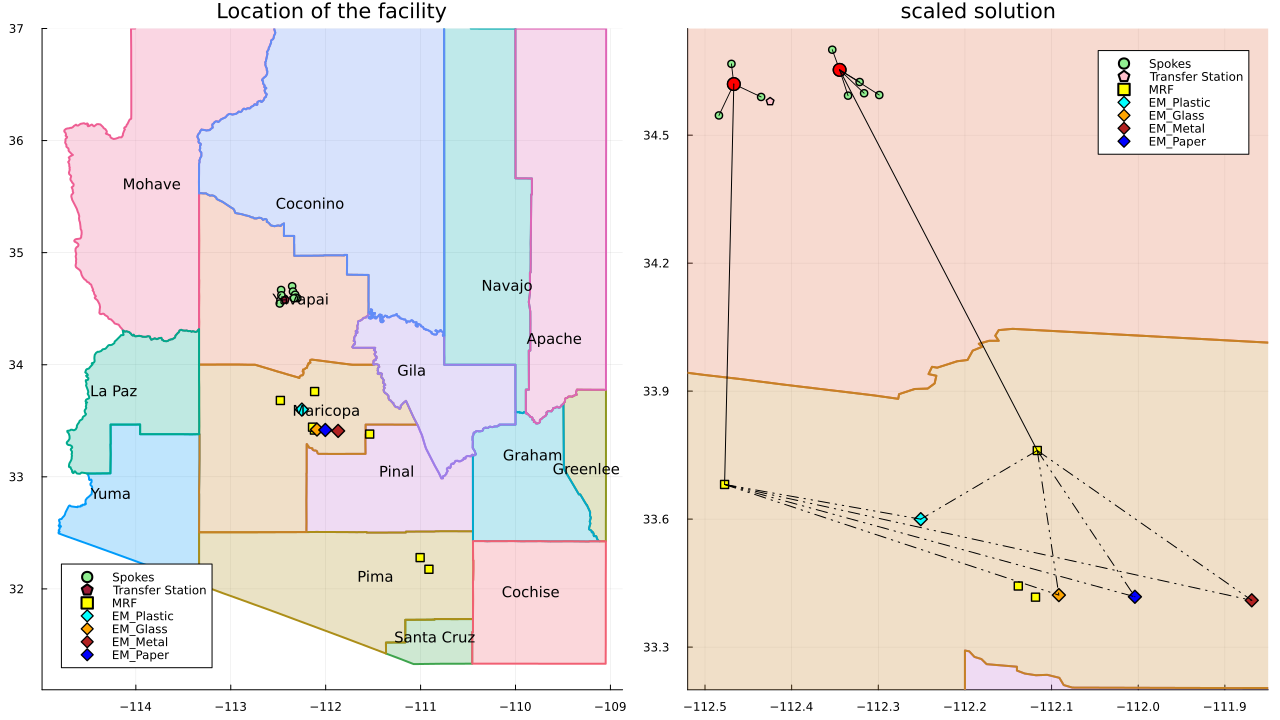

In [9]:
geo = JSON.parsefile("AZ.geojson")
features = geo["features"]
plot_shapes = []
counties = []

for feature in features
    coordinates = feature["geometry"]["coordinates"]
    county = feature["properties"]["name"]
    for ring in coordinates

        longitudes = [coord[1] for coord in ring]
        latitudes = [coord[2] for coord in ring]
        
        push!(plot_shapes, Shape(longitudes, latitudes))
        push!(counties, county)
    end
end

println("geography of ", length(plot_shapes), " counties.")
coordinates = geo["features"][2]["geometry"]["coordinates"][1]
longitudes = [coord[1] for coord in coordinates]
latitudes = [coord[2] for coord in coordinates]
data = DataFrame(plots_shapes=plot_shapes, value=rand(33.2:35, length(plot_shapes)), county=counties)
anim = Animation()

pp = plot()
qq = plot()

for (i, shape) in enumerate(data.plots_shapes)
    longitudes = shape.x
    latitudes = shape.y
    county_name = data.county[i]
    value = data.value[i]
    
    # regions
    plot!(pp, longitudes, latitudes, fillrange=0, fillalpha=0.25, size = (1280, 720), yrange = (33.2, 34.75), xrange=(-112.52, -111.85), label=false,
        linewidth=2, title = "scaled solution")
    plot!(qq, longitudes, latitudes, fillrange=0, fillalpha=0.25, yrange = (31.1, 37), size = (1280, 720), label=false, linewidth=2,
        title = "Location of the facility")
    # Calculate the centroid of the polygon (average of the coordinates)
    centroid_lon = mean(longitudes)
    centroid_lat = mean(latitudes)
    
    #  county name
    annotate!(qq, centroid_lon, centroid_lat, text(county_name, 10, :black))
end
scatter!(pp, S_dy, S_dx, markercolor = :lightgreen, label = "Spokes", markershape = :circle)
scatter!(pp, TS_dy, TS_dx, markercolor = :pink, label = "Transfer Station", markershape = :pentagon)
scatter!(pp, MRF_dy, MRF_dx, markercolor = :yellow, label = "MRF", markershape = :rect)
scatter!(pp, [EM_dy[1]], [EM_dx[1]], markercolor = :cyan, label = "EM_Plastic", markershape = :diamond, markersize = 2 .* (3.25))
scatter!(pp, [EM_dy[2]], [EM_dx[2]], markercolor = :orange, label = "EM_Glass", markershape = :diamond, markersize = 2 .* (3.25))
scatter!(pp, [EM_dy[3]], [EM_dx[3]], markercolor = :firebrick, label = "EM_Metal", markershape = :diamond, markersize = 2 .* (3.25))
scatter!(pp, [EM_dy[4]], [EM_dx[4]], markercolor = palette([:blue, :green], 7), label = "EM_Paper", markershape = :diamond, markersize = 2 .* (3.25))
for i in 1:O
    for j in 1:O
        if value.(x[i, j]) > 0.5
            if i==j
                spoke = scatter!(pp, [S_dy[i], S_dy[j]], [S_dx[i], S_dx[j]]; label = false, color = "red", markersize = 2 .* (3.5))
                frame(anim, spoke)
            end
            alloc = plot!(pp, [S_dy[i], S_dy[j]], [S_dx[i], S_dx[j]]; color=:black, linewidth=0.9, label = false)
            frame(anim, alloc)
        end
    end
end
for i in 1:O
    for j in 1:M
        if value.(f3[i, j]) > 0.5
            HMalloc = plot!(pp, [S_dy[i], MRF_dy[j]], [S_dx[i], MRF_dx[j]]; label = false, color = "black")
            frame(anim, HMalloc)
        end
    end
end
for i in 1:O
    for j in 1:T
        if value.(f2[i, j]) > 0.5
            # scatter!([MRF_dx[j], MRF_dy[j]], [MRF_dx[j], MRF_dy[j]]; legend = false, color = "yellow", markershape = :rect)
            STalloc = plot!(pp, [S_dy[i], TS_dy[j]], [S_dx[i], TS_dx[j]]; label = false, color = "cyan")
            frame(anim, STalloc)
        end
    end
end
for i in 1:T
    for j in 1:M
        if value.(f4[i, j]) > 0.5
            # scatter!([MRF_dx[j], MRF_dy[j]], [MRF_dx[j], MRF_dy[j]]; legend = false, color = "yellow", markershape = :rect)
            TMalloc = plot!(pp, [TS_dy[i], MRF_dy[j]], [TS_dx[i], MRF_dx[j]]; label = false, color = "pink")
            frame(anim, TMalloc)
        end
    end
end
for i in 1:M
    for j in 1:E
        if sum(value.(s1[1, i, j, :])) > 0.5
            MEalloc = plot!(pp, [MRF_dy[i], EM_dy[j]], [MRF_dx[i], EM_dx[j]]; linestyle = :dashdotdot,
                 linewidth=1, label = false, color = "black")
            frame(anim, MEalloc)
        end
    end
end
scatter_data = [
    (S_dy, S_dx, :lightgreen, "Spokes", :circle),
    (TS_dy, TS_dx, "#9C1D38", "Transfer Station", :pentagon),
    (MRF_dy, MRF_dx, :yellow, "MRF", :rect),
]
for (dy, dx, color, label, shape) in scatter_data
    scatter!(qq, dy, dx, markercolor=color, label=label, markershape=shape)
end
scatter!(qq, [EM_dy[1]], [EM_dx[1]], markercolor = :cyan, label = "EM_Plastic", markersize = 2 .* (3.25), markershape = :diamond)
scatter!(qq, [EM_dy[2]], [EM_dx[2]], markercolor = :orange, label = "EM_Glass", markersize = 2 .* (3.25), markershape = :diamond)
scatter!(qq, [EM_dy[3]], [EM_dx[3]], markercolor = :firebrick, label = "EM_Metal", markershape = :diamond, markersize = 2 .* (3.25))
scatter!(qq, [EM_dy[4]], [EM_dx[4]], markercolor = palette([:blue, :green], 7), label = "EM_Paper", markershape = :diamond, markersize = 2 .* (3.25))
plot(qq, pp)
# gif(anim, fps=5)

In [12]:
value.(x)

10×10 Matrix{Float64}:
  0.0   1.0   0.0   0.0   0.0   0.0  0.0  -0.0  -0.0  -0.0
  0.0   1.0  -0.0   0.0  -0.0  -0.0  0.0  -0.0  -0.0  -0.0
  0.0   1.0  -0.0   0.0   0.0   0.0  0.0  -0.0   0.0   0.0
  0.0   1.0   0.0  -0.0   0.0   0.0  0.0  -0.0   0.0   0.0
  0.0  -0.0  -0.0   0.0   0.0   0.0  0.0   1.0   0.0   0.0
  0.0  -0.0  -0.0   0.0   0.0  -0.0  0.0   1.0   0.0  -0.0
  0.0  -0.0  -0.0   0.0   0.0   0.0  0.0   1.0   0.0   0.0
 -0.0  -0.0  -0.0  -0.0  -0.0  -0.0  0.0   1.0  -0.0  -0.0
  0.0   1.0   0.0   0.0   0.0   0.0  0.0  -0.0   0.0   0.0
  0.0   1.0   0.0   0.0   0.0   0.0  0.0  -0.0   0.0   0.0

In [ ]:
set_optimizer_attribute(model, "CliqueCuts", 0)
set_optimizer_attribute(model, "CoverCuts", 0)
set_optimizer_attribute(model, "RLTCuts", 0)
set_optimizer_attribute(model, "FlowCoverCuts", 0)
set_optimizer_attribute(model, "MIRCuts", 0)
set_optimizer_attribute(model, "StrongCGCuts", 0)
set_optimizer_attribute(model, "GUBcoverCuts", 0)

In [ ]:
using JuMP, Dualization
undo = relax_integrality(model)
dm = dualize(model; dual_names = DualNames("", ""))
print(dm)

**Decomposition Algorithm**

In [34]:
# Big_V = [2197.2110999999995, 2293.9376999999995, 2015.1374999999994, 2331.8696999999993, 2031.2585999999992]
Big_V = zeros(N) 
mm = Model(CPLEX.Optimizer)
set_time_limit_sec(mm, 1800.0)
set_silent(mm)
# set_optimizer_attribute(model, "ImpliedboundCuts", 0)
# First stage variable (Here and Now)

@variable(mm, θ[1:N]>=-10)
@variable(mm, 0 <= x[1:O, 1:O] <=1, Bin)
@variable(mm, f2[1:O, 1:T] >=0)
@variable(mm, f3[1:O, 1:M] >=0)
@variable(mm, f4[1:T, 1:M] >=0)
# @variable(model, z1[1:M], Bin)
# @variable(model, y[1:O], Bin)
@variable(mm, ft[1:T] >=0)
@variable(mm, fh[1:O] >=0)

@constraint(mm, assgn[i in 1:O], sum(x[i, j] for j in 1:O) == 1)

@constraint(mm, assgn2[i in 1:O, j in 1:O], x[i, j] <= x[j,j])
@constraint(mm, cap[j in 1:O], sum(x[i, j] * b[i] for i in 1:O) <= cap_h[j] * x[j, j])
@constraint(mm, flow_h_t_m[j in 1:O], sum(f2[j, t] for t in 1:T) + sum(f3[j, m] for m in 1:M) == 
        sum(x[i, j] * b[i] for i in 1:O))
@constraint(mm, flow_t_a[t in 1:T], sum(f2[i, t] for i in 1:O) == sum(f4[t, m] for m in 1:M))

# List of Valid Inequalities

@constraint(mm, hub_VI, sum(x[j, j] for j in 1:O) >= ceil(sum(b[i] for i in 1:O)/maximum(cap_h)))
@constraint(mm, hub_bin_VI, sum(x[i, j] for i in 1: ceil(Int, O/5) for j in 1:O) - sum(x[j, j] for j in 1:O) <= ceil(O/5) -
    ceil(sum(b[i] for i in 1:ceil(Int, O/5))/maximum(cap_h)))
@constraint(mm, hub_res_VI, ceil(sum(b[i] for i in 1:ceil(Int, O/5))/maximum(cap_h)) - sum(x[i, j] for i in 1: ceil(Int, O/5) for j in 1:ceil(Int, O/5))
    <= sum(x[j, j] for j in (ceil(Int, O/5)+1):O))
@constraint(mm, hub_VIalt, sum(x[j, j] for j in 1:O) >= num)
@constraint(mm, hub_VI2, sum(cap_h[j] for j in 1:O) - maximum(cap_h) >= sum(b[i] * x[i, j] for i in 1:O for j in 1:O))
@constraint(mm, arc_ub[j in 1:O], sum(x[i, j] for i in 1:O if i!=j) <= (ub[j]) * x[j, j])

# @constraint(model, x[1,2] + x[1, 10] + x[2, 1] + x[2,10] + x[10, 1] + x[10, 2] <= 1)


# @constraint(model, 2 * (x[4, 5] + x[5, 6] + x[6, 7]) + x[4, 8] + x[5, 8] + x[6, 8] + sum(x[8, j] for j in 1:O if j!=8) <= 3)
# @constraint(model, flow_smb[i in 1:O, j in 1:O], !x[i, j] --> {f[i, j] <= big_M})
# @constraint(model, flow_ts[t in 1:T], ft[t] == sum(f2[i, t] for i in 1:O))
# @constraint(model, flow_hs[j in 1:O], fh[j] == sum(f[i, j] for i in 1:O))
# @constraint(model, flow_assgn[i in 1:O], sum(f[i, j] for j in 1:O) == sum(b[i] * x[i, j] for j in 1:O))
# @constraint(model, flow_smb[i in 1:O, j in 1:O], f[i, j] <= b[i] * x[i,j])
# @constraint(model, hub_VI_try[i in 1: floor(Int, O/5), j in ceil(Int, O/5):O], x[i, j] + x[j, j] <= 2)


spoke_hub = sum(c1[i, j] * x[i, j] * b[i] for i in 1:O for j in 1:O)
hub_transfer = sum(c2[i, j] * f2[i, j] for i in 1:O for j in 1:T)
hub_mrf = sum(c3[i, j] * f3[i, j] for i in 1:O for j in 1:M)
transfer_mrf = sum(c4[i, j] * f4[i, j] for i in 1:T for j in 1:M)
Hub_cap_cost = sum(cost_hub[j] * x[j, j] for j in 1:O) 

first_stage =  spoke_hub +  hub_transfer + hub_mrf + transfer_mrf + Hub_cap_cost
# unset_binary.(x)
@objective(mm, Min, first_stage + (1/N) * sum(θ[n] for n in 1:N))
# optimize!(mm)
# objective_value(mm)

LoadError: UndefVarError: `num` not defined

In [67]:
value.(θ)

50-element Vector{Float64}:
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
   ⋮
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0
 -10.0

In [13]:
using HiGHS
function solve_subproblem(f3, f4, u)
    sm = Model(CPLEX.Optimizer)
    # set_attribute(sm, "presolve", "off")
    set_silent(sm)
    @variable(sm, 0 <= w1[1:M, 1:Ph+1]) # continuous_Recourse variable(effective throughput)
    @variable(sm, 0 <= s1[1:M, 1:E, 1:Ph]) # continuous_Recourse variable(sorted recovery)

    con1 = @constraint(sm, d1[m in 1:M], w1[m, 1] == sum(f3[j,m] for j in 1:O) *r1[u, m]  + sum(f4[j,m] for j in 1:T) *r2[u, m])
    con2 = @constraint(sm, d2[m in 1:M], w1[m, 2] == sum(f3[i, m] for i in 1:O) + sum(f4[i, m] for i in 1:T)-sum(s1[m, e, 1] for e in 1:E))
    con3 = @constraint(sm, d3[m in 1:M, p in 2:Ph], w1[m, p+1] == w1[m,p] -sum(s1[m, e, p] for e in 1:E))
    
    # con3 = @constraint(sm, d3[m in 1:M, j in 1:E, p in 1:Ph], s1[m, j, p] <= big_M * y1[m, j])
    # con4 = @constraint(sm, d4[m in 1:M, j in 1:E], sum(s1[m, j, p] for p in 1:Ph) <= big_M * y1[m, j])
    con5 = @constraint(sm, d5[m in 1:M, p in 1:Ph], sum(s1[m, e, p] for e in 1:E) <= w1[m, 1]*Comp[p]*ef[u, m, p])
    # conb = @constraint(sm, db[m in 1:M, j in 1:E], y1[m, j] <= 1)
    con6 = @constraint(sm, d6[e in 1:E, p in 1:Ph], -sum(s1[m, e, p] for m in 1:M) <= -D * Comp[p] * sum(b[i] for i in 1:O) * (1/E))

    MRF_cost = c_Lf * (sum(w1[m, Ph+1] for m in 1:M))
    @objective(sm, Min, MRF_cost)
    optimize!(sm)
    if is_solved_and_feasible(sm; dual = true)
        return (is_feasible = true, obj = objective_value(sm), 
            w1 = value.(w1), s1 = value.(s1), π1 = dual.(con1), π2 = dual.(con2), π6 = dual.(con6)) # π3 = dual.(conb), π4 = dual.(con4)
    end
    return (is_feasible = false, v = dual_objective_value(sm),
          u1 = dual.(con), u2 = dual.(con2), u3 = dual.(conb), u6 = dual.(con6)) # u4 = dual.(con4)
end
function print_iteration(k, args...)
            f(x) = Printf.@sprintf("%12.4e", x)
            println(lpad(k, 9), " ", join(f.(args), " "))
            return
end
function store_results_to_csv(filename, O, T, M, E, N, gurobi_runtime, Multicut_runtime, Multicut_Nsp, Incremental_runtime, Incremental_Nsp, S)
    # Create a DataFrame with the results to be stored
    OTMEN = "$O-$T-$M-$E-$N"
    result = DataFrame(Instance=OTMEN, gurobi_runtime=gurobi_runtime, Multicut_runtime =Multicut_runtime, Multicut_Nsp = Multicut_Nsp, 
        Incremental_runtime = Incremental_runtime, Incremental_Nsp = Incremental_Nsp, Scenario=N)
    
    # If the file doesn't exist, create it and write the header
    if !isfile(filename)
        # Write header and data to a new file
        CSV.write(filename, result)
    else
        # Append data to the file
        CSV.write(filename, result, append=true)
    end
end

store_results_to_csv (generic function with 1 method)

In [54]:
MAXIMUM_ITERATIONS = 5000
ABSOLUTE_OPTIMALITY_GAP = 1e-6

store_results_to_csv (generic function with 1 method)

In [98]:
ABSOLUTE_OPTIMALITY_GAP = 1e-6
sp_solves = 0
gap = []
# Initialize variables
Flag_Status = true
π1_history = []
π2_history = []
π6_history = []

function my_callback(cb_data)
    status = callback_node_status(cb_data, mm)

    # Only add constraints if the node is an integer solution
    if status != MOI.CALLBACK_NODE_STATUS_INTEGER
        return
    end

    # Read values from the callback data
    x_k = callback_value.(cb_data, x)
    f2_k = callback_value.(cb_data, f2)
    f3_k = callback_value.(cb_data, f3)
    f4_k = callback_value.(cb_data, f4)
    θ_k = callback_value.(cb_data, θ)
    first_stage_k = callback_value.(cb_data, first_stage)
    lower_bound = first_stage_k + (1 / N) * sum(θ_k)

    global k
    revisited_u = Set()  # Set to track which u have been revisited (to avoid re-checking them)
    add_constraint_needed = false  # Flag to track if a constraint is needed

    # Phase 1: Check the gap condition for all u <= N
    for u in 1:min(k, N)  # Ensure we only check up to N
        
            ret = solve_subproblem(f3_k, f4_k, u)
            upper_bound = first_stage_k + ret.obj
            ac_lb = lower_bound - (1 / N) * sum(θ_k) + θ_k[u]
            gap = abs(upper_bound - ac_lb) / upper_bound

            # If the gap is larger than the threshold, add a constraint and revisit this u
            if gap >= ABSOLUTE_OPTIMALITY_GAP
                if u in revisited_u  # Only check if we haven't already revisited this u
                    delete!(revisited_u, u)  # Only check if we haven't already revisited this u)
                    println("$u needs further cuts")
                end
                global sp_solves += 1
                cut = @build_constraint(
                    θ[u] >= sum(ret.π1[m] * r1[u, m] * sum(f3[i, m] for i in 1:O) for m in 1:M) +
                    sum(ret.π1[m] * r2[u, m] * sum(f4[i, m] for i in 1:T) for m in 1:M) +
                    sum(ret.π2[m] * sum(f3[i, m] for i in 1:O) for m in 1:M) +
                    sum(ret.π2[m] * sum(f4[i, m] for i in 1:T) for m in 1:M)  -
                    D * (1 / E) * sum(b[i] for i in 1:O) * sum(ret.π6[e, p] * Comp[p] for p in 1:Ph for e in 1:E)
                )
                # @info("add a cut for $u")
                MOI.submit(mm, MOI.LazyConstraint(cb_data), cut)
            else
                # @info("$u reach gap")
                push!(revisited_u, u)
            end
    end

    # If we have added any constraints, the callback will continue and check again

    if k <= N
            @info("add next sample subset")
            k += R
    end

    # If all u have met the gap condition
    if length(revisited_u) == N
        return  # Exit the callback 
    end
    return
end
set_attribute(mm, MOI.LazyConstraintCallback(), my_callback)

In [95]:
println("Iteration  Lower Bound  Upper Bound          Gap         ret")
k = N # Initial value of k (number of scenarios to check)
R = 100
optimize!(mm)
Multicut_runtime = solve_time(mm)
Multicut_Nsp = sp_solves
println("total inner loop iterations required: $Multicut_Nsp")
println("total CPU runtime: ", Multicut_runtime)
objective_value(mm)

Iteration  Lower Bound  Upper Bound          Gap         ret


[ Info: add next sample subset


total inner loop iterations required: 9500
total CPU runtime: 490.4319999217987


142981.56257930177

In [99]:
println("Iteration  Lower Bound  Upper Bound          Gap         ret")
k = 10 # Initial value of k (number of scenarios for Incremental Benders)
R = 15
optimize!(mm)
Incremental_runtime = solve_time(mm)
Incremental_Nsp = sp_solves
println("total inner loop iterations required: $Incremental_Nsp")
println("total CPU runtime: ", Incremental_runtime)
objective_value(mm)

Iteration  Lower Bound  Upper Bound          Gap         ret


[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: add next sample subset
[ Info: 

total inner loop iterations required: 4926
total CPU runtime: 434.7039999961853


142981.5625793022

In [42]:
store_results_to_csv("Comparison.csv", O, T, M, E, N, gurobi_runtime, Multicut_runtime, Multicut_Nsp, Incremental_runtime, Incremental_Nsp, N, O, T, M, E)

LoadError: UndefVarError: `gurobi_runtime` not defined

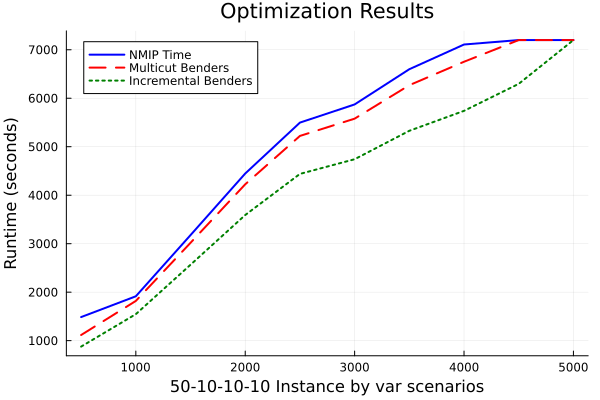

In [19]:
function cases(dfm, O_value, T_value, M_value, E_value)
    Nodes = split.(dfm.Instance, "-") 
    Vertex_Instances = [(Node[1] == string(O_value)) && 
            (Node[2] == string(T_value)) && 
            (Node[3] == string(M_value)) && 
            (Node[4] == string(E_value)) for Node in Nodes]
    
    return dfm[Vertex_Instances, :]
end
dfm = CSV.File("Comparison.csv") |> DataFrame
df = cases(dfm, O, T, M, E)
Instance = df.Scenario
NMIP_time = df.gurobi_runtime
Multicut_Benders = df.Multicut_runtime
Incremental_Benders = df.Incremental_runtime
plot(Instance, [NMIP_time Multicut_Benders Incremental_Benders], 
     label=["NMIP Time" "Multicut Benders" "Incremental Benders"],  # Label for each line
     xlabel="$O-$T-$M-$E Instance by var scenarios",  # Common x-axis title
     ylabel="Runtime (seconds)",  # Common y-axis title
     linewidth=2,
     legend=:topleft,  # Place the legend in the top-right corner
     title="Optimization Results",  # Plot title
     grid=true,  # Enable grid for better readability
     color=[:blue :red :green],  # Color for each series
     linestyle=[:solid :dash :dot])  # Line style for each series

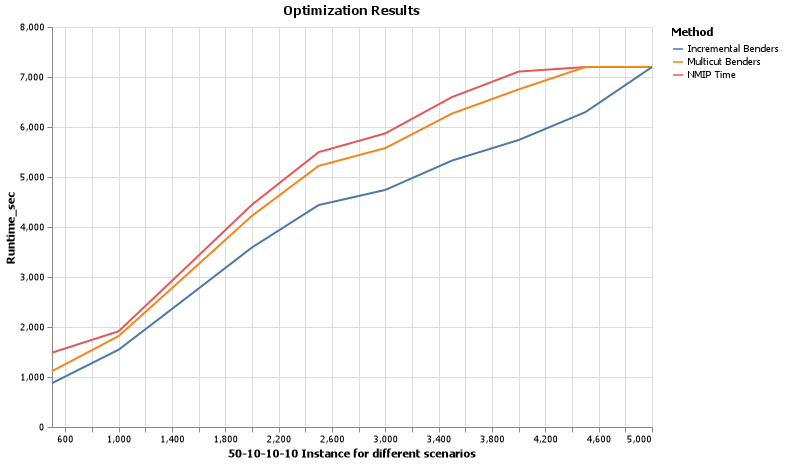

In [20]:
df_long = DataFrame(
    Instance = repeat(Instance,  outer = 3), 
    Runtime_sec = vcat(NMIP_time, Multicut_Benders, Incremental_Benders),  
    Method = repeat(["NMIP Time", "Multicut Benders", "Incremental Benders"], inner=length(Instance)) 
)

# Now plot using VegaLite
@vlplot(
    :line,
    x = {:Instance, title = "$O-$T-$M-$E Instance for different scenarios"},   
    y = :Runtime_sec,                 
    color = :Method,                
    data = df_long,                
    width = 600, 
    height = 400,
    linestyle=[:solid :dash :dot],
    title = "Optimization Results",
)

In [135]:
println("Iteration  Lower Bound  Upper Bound          Gap         ret")
optimal_reached = false
π1_history = []
π2_history = []
π6_history = []

# Keep track of whether a Bender's cut is added for a particular u
optimal_u_values = Set{Int}()
last_optimal_status = Dict{Int, Bool}()
total_inner_iterations = 0  # Initialize the counter for inner iterations

@time begin
 for k in 1:MAXIMUM_ITERATIONS
    optimize!(mm)
    lower_bound = objective_value(mm)
    # println("Lower Bound: $lower_bound")

    x_k = value.(x)
    f2_k = value.(f2)
    f3_k = value.(f3)
    f4_k = value.(f4)
    θ_k  = value.(θ)
    first_stage_k = value.(first_stage)

    for u in 1:70+300*k # Iterate over all u (up to N)
      if u<=N && !(u in optimal_u_values)
        

        # Only process if it's either not optimal, or we haven't checked it before
        ret = solve_subproblem(f3_k, f4_k, u)
        
        if ret.is_feasible
            upper_bound = first_stage_k + ret.obj
            ac_lb = lower_bound - (1/N) * sum(θ_k) + θ_k[u]
            gap = abs(upper_bound - ac_lb) / upper_bound
            # print_iteration(k, ac_lb, upper_bound, gap, ret.obj)

            if gap < ABSOLUTE_OPTIMALITY_GAP
                # println("Optimality achieved for u = $u (gap < threshold)")
                push!(optimal_u_values, u)  # Mark u as optimal

            else
                cut = @constraint(mm, θ[u] >= sum(ret.π1[m] * r1[u, m] * sum(f3[i, m] for i in 1:O) for m in 1:M) +
                        sum(ret.π1[m] * r2[u, m] * sum(f4[i, m] for i in 1:T) for m in 1:M) +
                        sum(ret.π2[m] * sum(f3[i, m] for i in 1:O) for m in 1:M) +
                        sum(ret.π2[m] * sum(f4[i, m] for i in 1:T) for m in 1:M)  - 
                        D * (1/E) * sum(b[i] for i in 1:O) * sum(ret.π6[e,p] * Comp[p] for p in 1:Ph for e in 1:E)
                    )
                # println("Added Benders cut for u = $u")
                total_inner_iterations += 1  # Increment inner iteration count when a cut is added

            end
        else
            # If not feasible, generate the cut with u1 and u2
            cut = @constraint(mm, 0 >= sum(ret.u1[m] * r1[u, m] * sum(f3[i, m] for i in 1:O) for m in 1:M) +
                    sum(ret.u1[m] * r2[u, m] * sum(f4[i, m] for i in 1:T) for m in 1:M) +
                    sum(ret.u2[m] * sum(f3[i, m] for i in 1:O) for m in 1:M) +
                    sum(ret.u2[m] * sum(f4[i, m] for i in 1:T) for m in 1:M) -
                    D * (1/E) * sum(b[i] for i in 1:O) * sum(ret.u6[e,p] * Comp[p] for p in 1:Ph for e in 1:E)
            )
            println("Added cut for infeasible u = $u")
            total_inner_iterations += 1  # Increment inner iteration count when a cut is added
        end
      end
    end

    # After finishing all u iterations for this k, check if optimal was reached for all u
    # If any `u` isn't optimal, we will continue generating cuts
    if all(u in optimal_u_values for u in 1:N) && k < MAXIMUM_ITERATIONS
        println("No further Benders Cut, reached Optimal for all u")
        break  # exit outer loop (k loop) if optimal has been reached for all u
    else
        println("Proceeding to next iteration, still checking for optimality for u")
    end
 end
end
println("Total inner loop iterations: $total_inner_iterations")

Iteration  Lower Bound  Upper Bound          Gap         ret
Proceeding to next iteration, still checking for optimality for u
Proceeding to next iteration, still checking for optimality for u
Proceeding to next iteration, still checking for optimality for u
Proceeding to next iteration, still checking for optimality for u
Proceeding to next iteration, still checking for optimality for u
Proceeding to next iteration, still checking for optimality for u
Proceeding to next iteration, still checking for optimality for u
Proceeding to next iteration, still checking for optimality for u
Proceeding to next iteration, still checking for optimality for u
Proceeding to next iteration, still checking for optimality for u
Proceeding to next iteration, still checking for optimality for u
No further Benders Cut, reached Optimal for all u
320.504679 seconds (437.56 M allocations: 18.599 GiB, 4.22% gc time, 0.63% compilation time)
Total inner loop iterations: 13390


In [136]:
# set_binary.(x)
@time optimize!(mm)
objective_value(mm)
# value.(θ)
# π1_history

  0.022180 seconds (4.80 k allocations: 116.438 KiB)


89370.75395888445

In [2]:
include("SAA_backup.jl")

LoadError: SystemError: opening file "C:\\Users\\wahad\\Stochastic Hub and Spoke Code\\SAA_backup.jl": No such file or directory